In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy.stats import kruskal, pearsonr, spearmanr
from sklearn.preprocessing import LabelEncoder

### Importation et nettoyage des données

In [2]:
# Importation des données
df = pd.read_csv("../data/Train_clicks.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 289926 entries, 0 to 289925
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   impressions         289526 non-null  float64
 1   clicks              289526 non-null  float64
 2   cost                289526 non-null  float64
 3   conversions         289526 non-null  float64
 4   ad_type             289526 non-null  str    
 5   currency            289526 non-null  str    
 6   ID                  289926 non-null  str    
 7   date                289926 non-null  str    
 8   call_type           36900 non-null   str    
 9   call_status         36900 non-null   str    
 10  start_time          36900 non-null   str    
 11  duration            36900 non-null   float64
 12  end_time            36900 non-null   str    
 13  display_location    36900 non-null   str    
 14  impression_share    289926 non-null  float64
 15  conversions_calls   280071 non-null  float64


In [3]:
# On supprime les observations pour lesquelles la target est manquante
df_train = df[~df["clicks"].isna()].copy()
df_train.reset_index(drop=True, inplace=True)

# conversion en format date
df_train['date'] = pd.to_datetime(df_train['date'])

# Delete des colonnes qui ont trop de valeurs manquantes
df_train.drop(['call_type', 'call_status', 'start_time', 'duration', 'end_time', 'display_location', 'conversions_calls',
                'conversions'], axis=1, inplace=True)

In [4]:
display(df_train.shape)
display(df_train.tail())
df_train.head()

(289526, 11)

,impressions,clicks,cost,ad_type,currency,ID,date,impression_share,headline1_len,headline2_len,ad_description_len
289521,299.0,29.0,6809.716151,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,5.0,13.0
289522,410.0,28.0,6598.474957,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,16.0
289523,281.0,11.0,3642.348176,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,14.0
289524,41.0,5.0,547.477180,EXPANDED_DYNAMIC_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,0.0,0.0,0.0
289525,77.0,1.0,394.983536,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.99,1.0,4.0,13.0


,impressions,clicks,cost,ad_type,currency,ID,date,impression_share,headline1_len,headline2_len,ad_description_len
0,142.0,15.0,3393.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,5.0,11.0
1,89.0,8.0,1817.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0
2,59.0,8.0,1743.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,10.0
3,78.0,4.0,917.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,3.0,13.0
4,20.0,1.0,217.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0


### Exploration des données et Preprocessing

In [5]:
df_train.columns

Index(['impressions', 'clicks', 'cost', 'ad_type', 'currency', 'ID', 'date',
       'impression_share', 'headline1_len', 'headline2_len',
       'ad_description_len'],
      dtype='str')

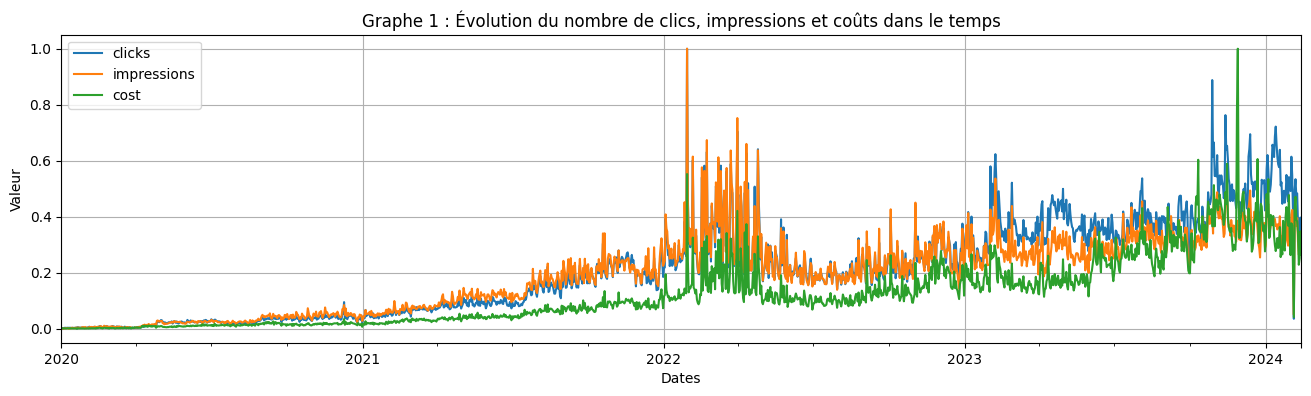

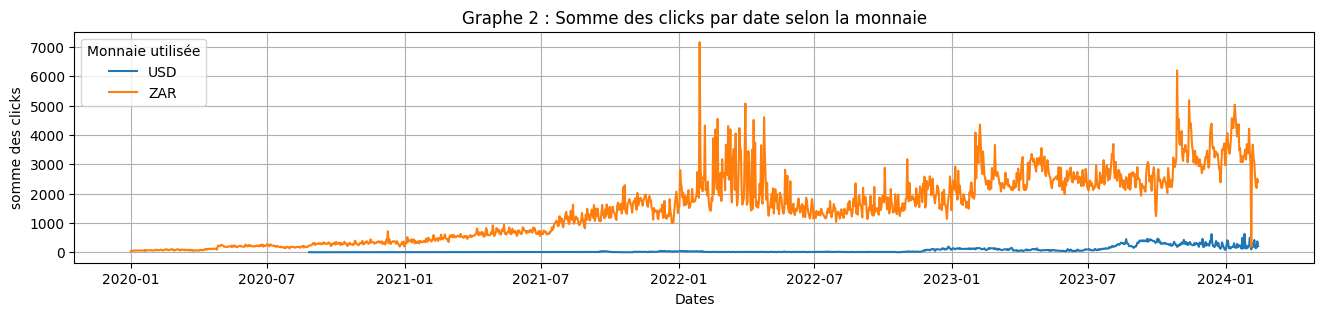

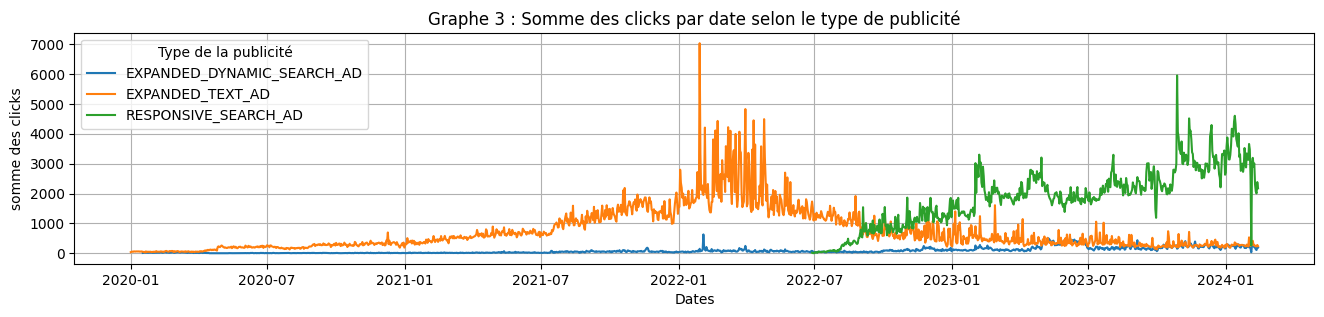

In [6]:
# Graphe de l'évolution dans le temps du nombre de clics, impressions et coûts sur publicités fait par les clients
df_sum_clicks = df_train.groupby(['date'])[['clicks', 'impressions', 'cost']].sum().reset_index()
cols = ['clicks', 'impressions', 'cost']
df_sum_clicks[cols] = (df_sum_clicks[cols] - df_sum_clicks[cols].min()) / (df_sum_clicks[cols].max() - df_sum_clicks[cols].min())
df_sum_clicks.plot( x='date',  y=cols,  figsize=(16, 4))
plt.xlabel('Dates')
plt.ylabel('Valeur')
plt.title('Graphe 1 : Évolution du nombre de clics, impressions et coûts dans le temps')
plt.legend()
plt.grid(True)
plt.show()

# Graphe de l'évolution dans le temps du nombre de clics sur publicités fait par les clients selon la monnaie utilisée
df_sum_clicks_currency = df_train.groupby(['currency', 'date'])['clicks'].sum().reset_index()
plt.figure(figsize=(16,3))
sns.lineplot(data=df_sum_clicks_currency, x='date', y='clicks', hue='currency')
plt.xlabel("Dates")
plt.ylabel('somme des clicks')
plt.title('Graphe 2 : Somme des clicks par date selon la monnaie')
plt.legend(title='Monnaie utilisée')
plt.grid(True)
plt.show()

# Graphe de l'évolution dans le temps du nombre de clics sur publicités fait par les clients selon le type de publicité
df_sum_clicks_par_ad = df_train.groupby(['ad_type', 'date'])['clicks'].sum().reset_index()
plt.figure(figsize=(16,3))
sns.lineplot(data=df_sum_clicks_par_ad, x='date', y='clicks', hue='ad_type')
plt.xlabel("Dates")
plt.ylabel('somme des clicks')
plt.title('Graphe 3 : Somme des clicks par date selon le type de publicité')
plt.legend(title='Type de la publicité')
plt.grid(True)
plt.show()

1. **Graphique 1**
 - On note une tendance globale fortement croissante des trois (03) métriques entre 2020 et 2024. Avec la digitalisation croissante, de plus en plus d'entreprises déplacent leurs efforts marketing vers le numérique, d'où l'augmentation des investissements publicitaires en ligne et ainsi la hausse du nombres de clics.
 - On remarque aussi qu'il y'a 3 phases dans la série des clics : 
   * *2020 - mi 2021* : niveau faible mais en croissance progressive
   * *fin 2021 - début 2022* : forte hausse et grande volatilité (pics très marqués allant jusqu'en 7000 clics)
   * *mi 2022 - 2024* : Stabilisation toujours avec tendance croissante, mais avec des fluctuations plus modérées

2. **Graphique 2**
 - La quasi-totalité des clics provient de la monnaie ZAR.
 - La courbe USD est très basse sur toute la période, avec une légère hausse fin 2023.
 - Les pics observés dans le graphe 1 sont presque exclusivement dus à ZAR.

3. **Graphique 3**
 - *EXPANDED_TEXT_AD* :
   * dominant jusqu’à mi-2022
   * chute progressive ensuite

 - *RESPONSIVE_SEARCH_AD* :
   * apparaît vers mi-2022
   * croissance rapide et devient le format dominant en 2023–2024
  Il semblerait qu'il y' ait un changement structurel de stratégie publicitaire avec l'abandon progressive des EXPANDED_TEXT_AD et l'adoption massive des RESPONSIVE_SEARCH_AD. Le type de publicité influence donc le niveau des clics.

 - *EXPANDED_DYNAMIC_SEARCH_AD* :
   * contribution très faible sur toute la période

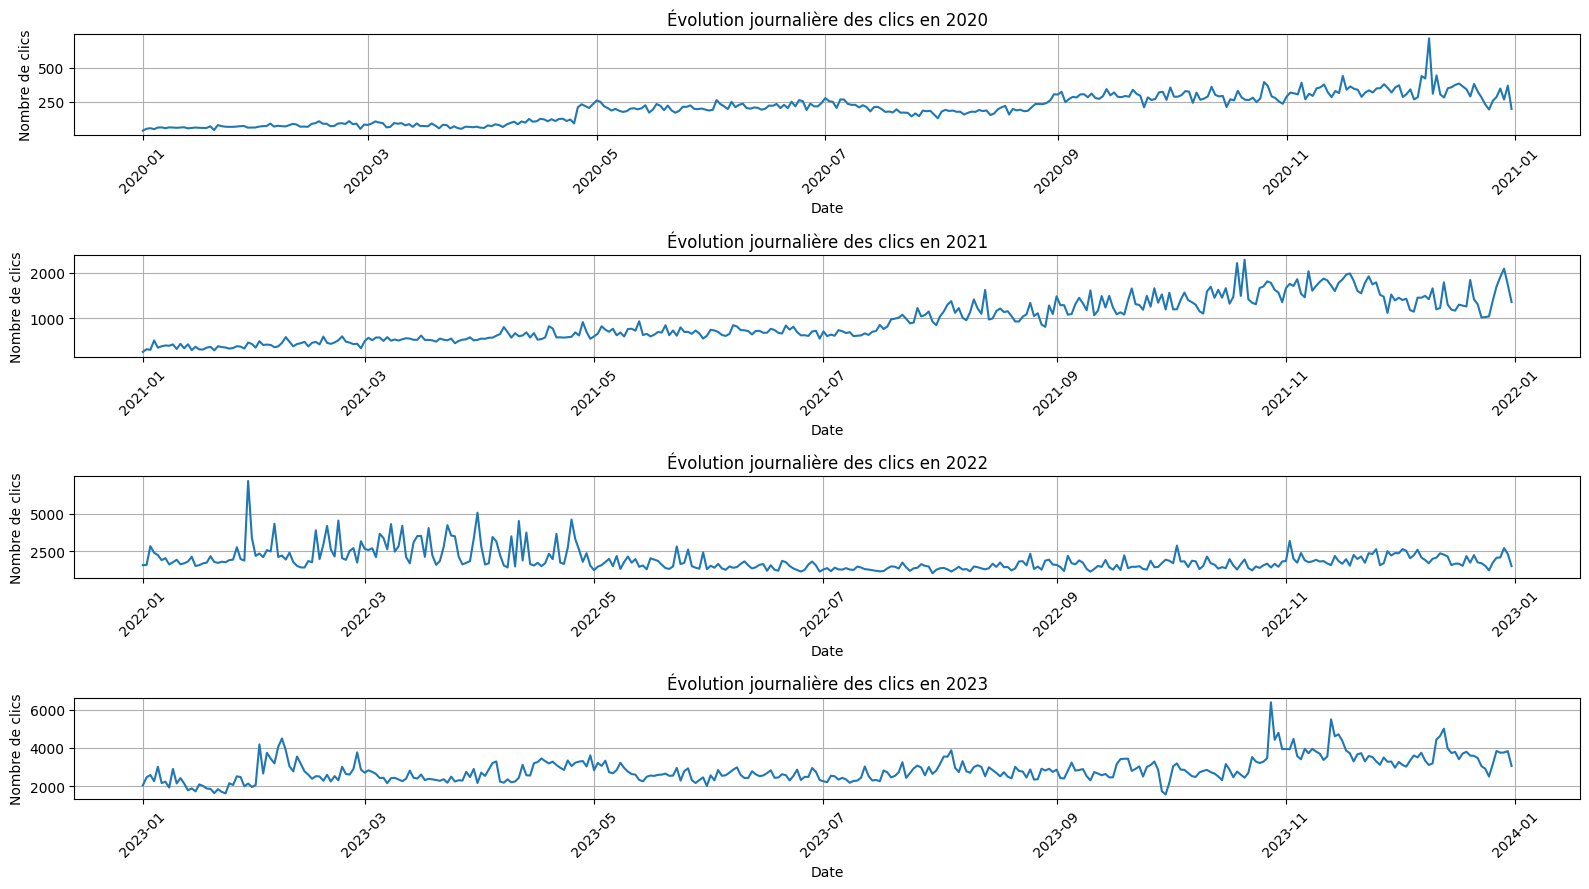

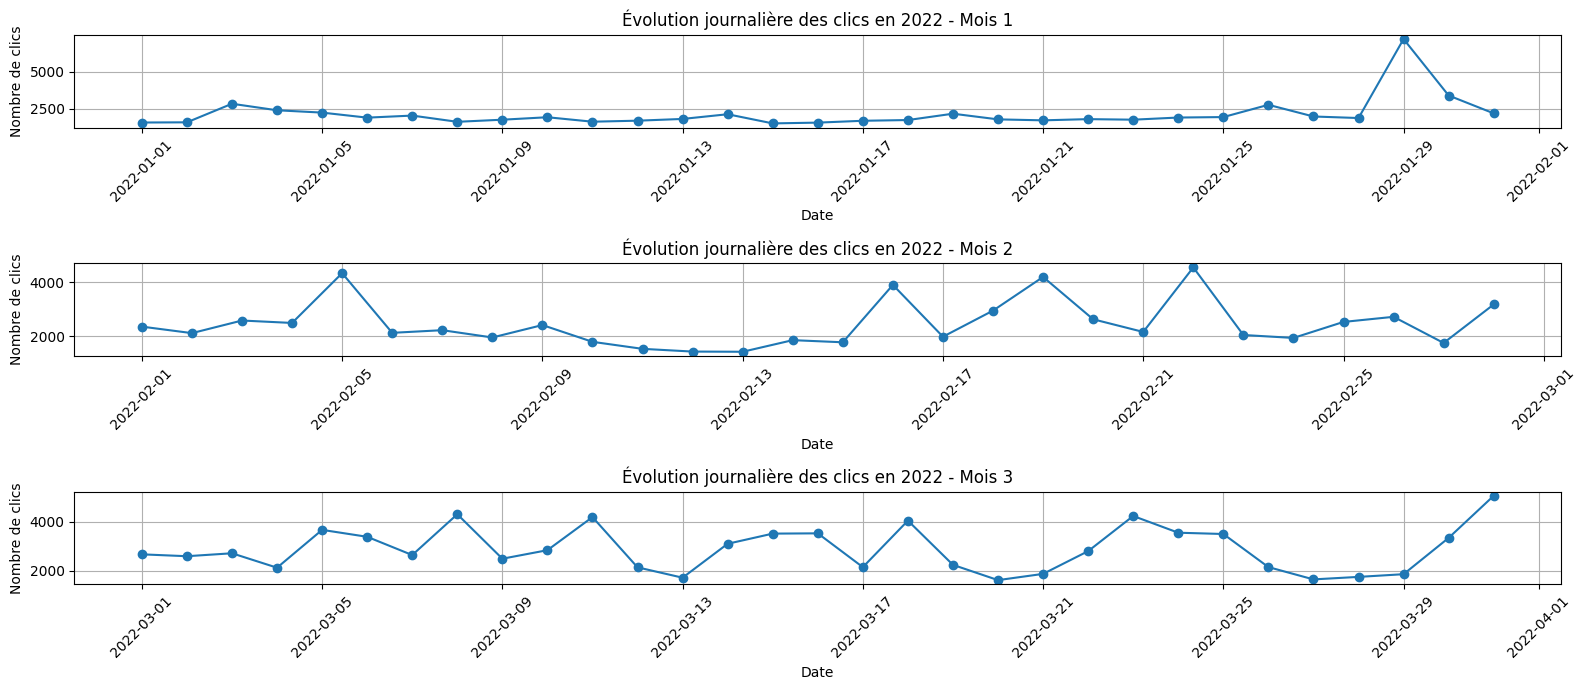

In [7]:
#### Evolution des clics (zoom sur les années et les mois pour voir s'il y'a une saisonnalité) ###################""

## Pour les années 2020, 2021, 2022 et 2023
annees = [2020, 2021, 2022, 2023]
plt.figure(figsize=(16, 9))  # 3 graphiques verticalement

for i, annee in enumerate(annees, 1):
    df_year = df_train[df_train['date'].dt.year == annee]
    daily_clicks = df_year.groupby('date')['clicks'].sum()
    
    plt.subplot(len(annees), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values)
    plt.title(f"Évolution journalière des clics en {annee}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Pour les mois de Janvier, Février et Mars de l'annéé 2022
annee_zoom = 2022
mois_zoom = [1, 2, 3]  # Janvier, février, mars
df_zoom = df_train[(df_train['date'].dt.year == annee_zoom) & (df_train['date'].dt.month.isin(mois_zoom))]
plt.figure(figsize=(16, 7))

for i, mois in enumerate(mois_zoom, 1):
    df_month = df_zoom[df_zoom['date'].dt.month == mois]
    daily_clicks = df_month.groupby('date')['clicks'].sum()
    
    plt.subplot(len(mois_zoom), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values, marker='o')
    plt.title(f"Évolution journalière des clics en {annee_zoom} - Mois {mois}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Il n'y a pas de saisonnalité apparente. Cependant ici on considère la somme des clics tout clients confondus. Il serait judicieux d'analyser la série pour chaque client pris individuellement.

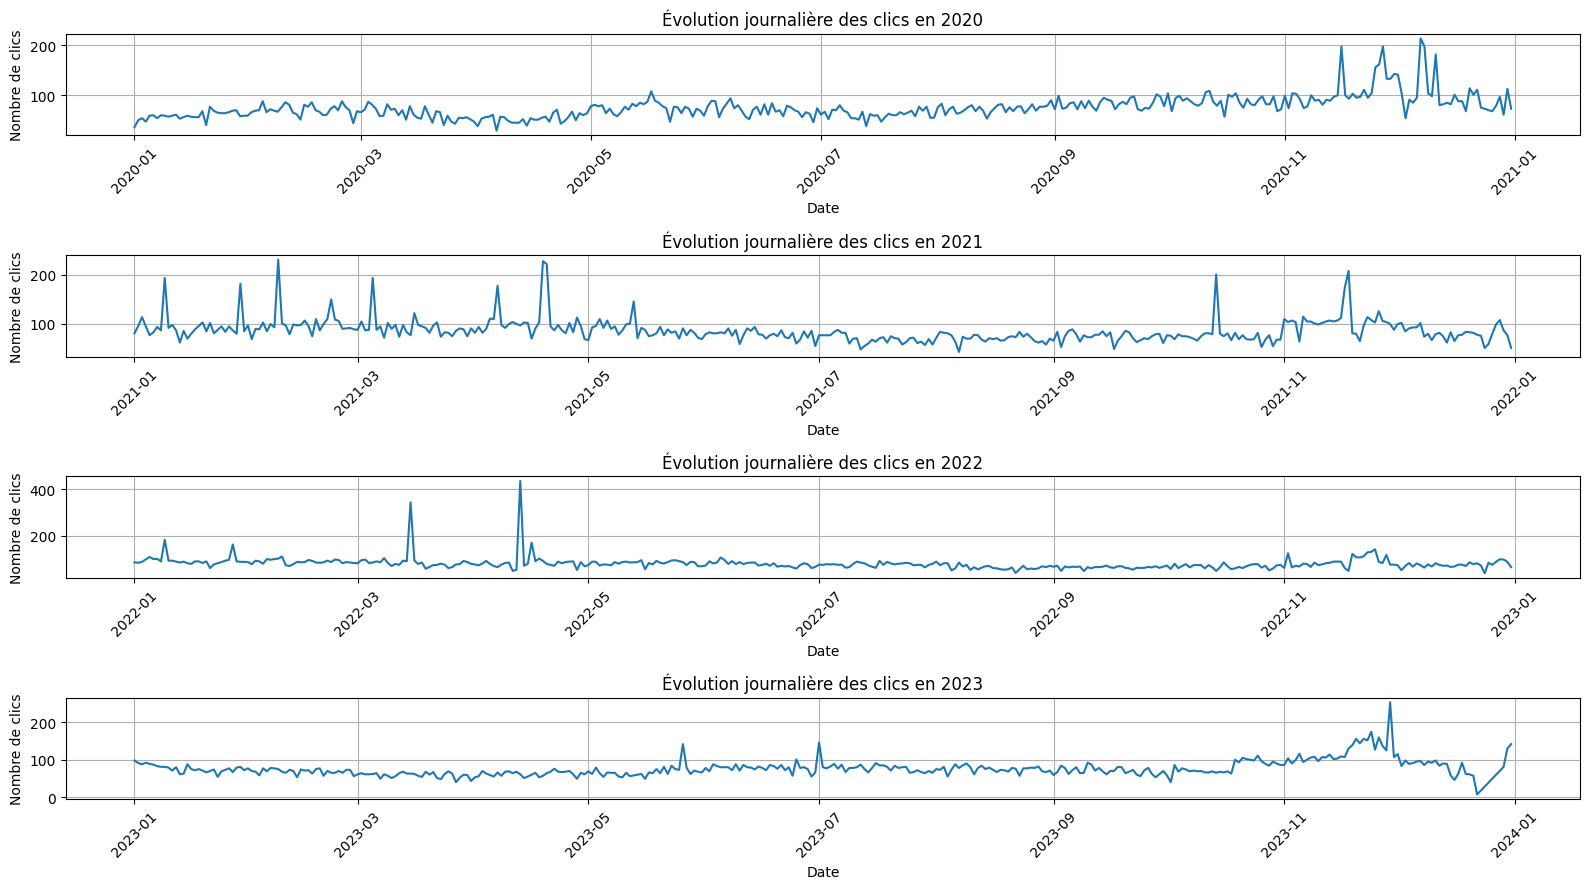

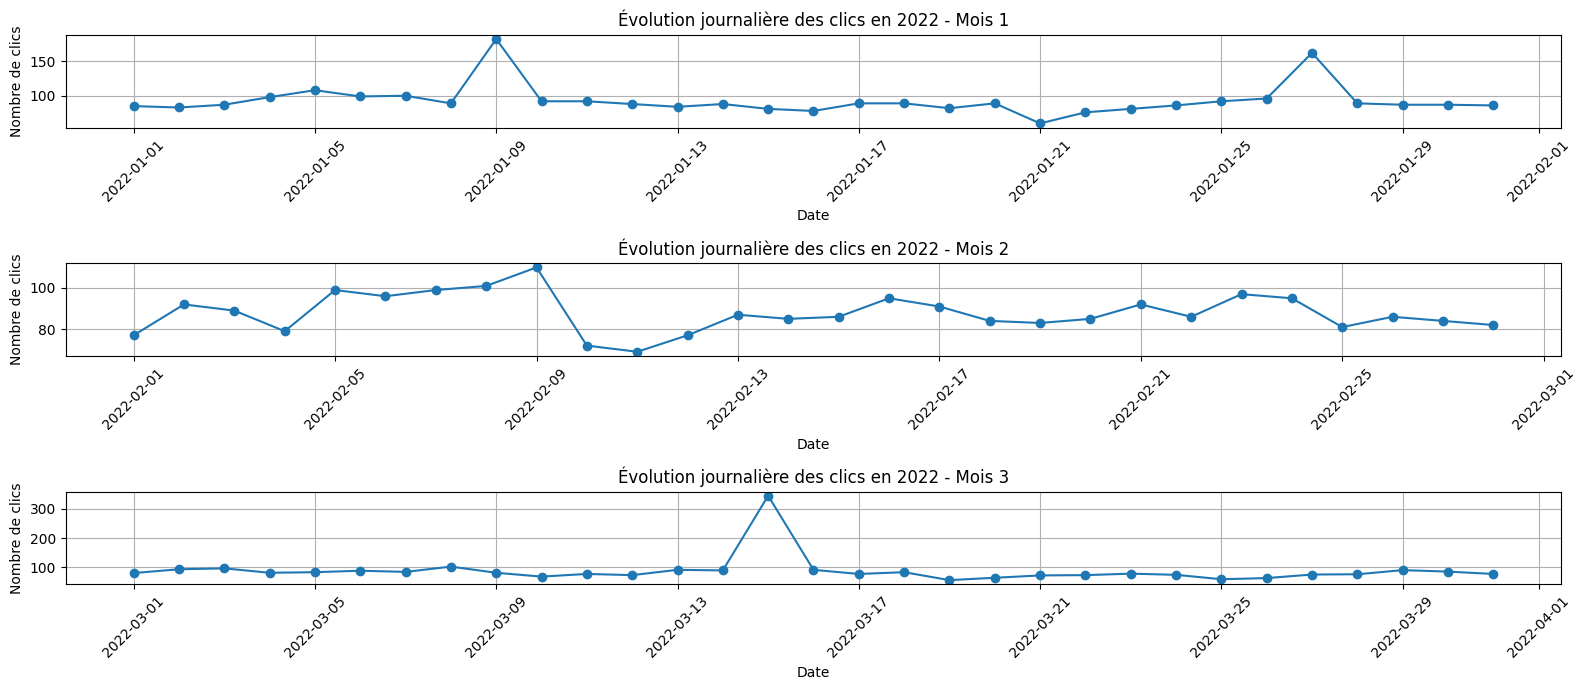

In [8]:
liste_id = df_train['ID'].unique()
i = 0
df_train_id = df_train[df_train['ID']==liste_id[i]]

## Pour les années 2020, 2021, 2022 et 2023
annees = [2020, 2021, 2022, 2023]
plt.figure(figsize=(16, 9))  # 3 graphiques verticalement

for i, annee in enumerate(annees, 1):
    df_year = df_train_id[df_train_id['date'].dt.year == annee]
    daily_clicks = df_year.groupby('date')['clicks'].sum()
    
    plt.subplot(len(annees), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values)
    plt.title(f"Évolution journalière des clics en {annee}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Pour les mois de Janvier, Février et Mars de l'annéé 2022
annee_zoom = 2022
mois_zoom = [1, 2, 3]  # Janvier, février, mars
df_zoom = df_train_id[(df_train_id['date'].dt.year == annee_zoom) & (df_train_id['date'].dt.month.isin(mois_zoom))]
plt.figure(figsize=(16, 7))

for i, mois in enumerate(mois_zoom, 1):
    df_month = df_zoom[df_zoom['date'].dt.month == mois]
    daily_clicks = df_month.groupby('date')['clicks'].sum()
    
    plt.subplot(len(mois_zoom), 1, i)
    plt.plot(daily_clicks.index, daily_clicks.values, marker='o')
    plt.title(f"Évolution journalière des clics en {annee_zoom} - Mois {mois}")
    plt.xlabel("Date")
    plt.ylabel("Nombre de clics")
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Bien qu’aucune saisonnalité marquée ne soit directement perceptible à l’œil nu dans les visualisations globales, cela n’exclut pas l’existence de motifs saisonniers plus fins. La présence d’une tendance forte, de pics extrêmes et l’agrégation des données peuvent masquer des effets saisonniers de faible amplitude mais réguliers. L’introduction de variables temporelles explicites (jour de la semaine, mois, semaine de l’année) permet aux modèles d’exploiter ces régularités, même lorsqu’elles ne sont pas immédiatement visibles dans les graphiques.

### Features Engineering

In [9]:
df_train.sort_values(by = ['ID', 'date'], inplace=True)

In [51]:
def semaine_du_mois(valeur_date):
    """Calcul à quelle semaine du mois appartient la date."""
    result = valeur_date.day + valeur_date.replace(day=1).weekday()
    return int(np.ceil(result / 7))

liste_jours_feries = [
        (16, 12), # Jour de la réconciliation
        (25, 12), # fête de Noël
        (1, 1),   # Jour du nouvel an
        (27, 4),  # Jour de la liberté
        (1, 5),   # fête du travail
        (9, 8),   # Jour National de la femme
        (24, 9),  # Journée du patrimoine
        (26, 12),  # Jour de la Bonne Volonté
        (21, 3),  # Jour des droits de l'homme
        (16, 6),  # fête de la jeunesse
    ]

def template_train_set(df, id):
    """Construit le dataframe de telle manière à garantir une ligne par jour (aucun trou temporel), même si le client
    n'avait pas de données certains jours."""
    dates = pd.date_range(start=df['date'].min(), end=df['date'].max())
    df_avec_toutes_les_dates = pd.DataFrame({'date' : dates, 'ID' : id})
    result = pd.merge(df_avec_toutes_les_dates, df, on=['date', 'ID'], how='left')
    return result

def features_date(df):
    """Fonction qui calcule les nouvelles features à partir de la date (pour capter si possible la saisonnalité si elle existe)."""
    ## features temporelles
    df['jour'] = df['date'].dt.day # extraction du jour du mois correspondant à la date du clic
    df['annee'] = df['date'].dt.year # annee conrrespondante à la date du clic
    df['mois'] = df['date'].dt.month # mois correspondant à la date du clic
    df['semaine'] = df['date'].dt.isocalendar().week # numero de la semaine de l'année (selon la norme ISO)
    df['jour_de_annee'] = df['date'].dt.dayofyear # extraction du rang du jour dans l'annee
    df['jour_de_semaine'] = df['date'].dt.dayofweek # extraction du rang du jour de la semaine
    df['trismestre_annee'] = df['date'].dt.quarter # trimestre de l'annee correspondant à la date
    df['weekend'] = df['date'].dt.dayofweek >= 5 # variable booleenne weekend (1 si oui 0 sinon)
    df['premier_du_mois'] = df['date'].dt.is_month_start.astype(int) # premier jour du mois (booleen)
    df['dernier_du_mois'] = df['date'].dt.is_month_end.astype(int)  # dernier jour du mois (booleen)
    df['semaine_du_mois'] = df['date'].apply(semaine_du_mois)  # extraction de la semaine du mois
    df['jours_ferie'] = df['date'].apply(lambda d: any(abs((d - pd.Timestamp(year=d.year, month=m, day=j)).days) <= 1
                  for j, m in liste_jours_feries)) # 1 si le jour est férié ou à la veille et le lendemain d'un jour férié
    df['post_change'] = df['date'] >= '2022-06-01' # Pour capturer un changement le régime (entre le type de publicité)
    return df

def features_cat(df):
    ad_type_dummies = pd.get_dummies(df['ad_type'], dtype=bool)
    currency_dummies = pd.get_dummies(df['currency'], dtype=bool)
    df = pd.concat([df, ad_type_dummies], axis=1)
    df = pd.concat([df, currency_dummies], axis=1)
    df.drop(['ad_type', 'currency'], axis=1, inplace=True)
    return df

def features_lags(df, cols, lags, lags_diff):
    """Calcul des lags et des différences entre lags."""
    df.sort_values(by = ['date'], inplace=True)
    # lags
    for col in cols:
            for shift in lags:
                df[f"lag_{col}_{shift}"] = df[col].shift(shift)
    
    # différences entre lags
    for col in cols:
            for shift in lags_diff:
                df[f"diff_{col}_lag_{shift}"] = df[f"lag_{col}_{lags_diff[0]}"] - df[f"lag_{col}_{shift}"]
    return df

def features_stat_semaine(df):
     """Calcul des features statistiques par semaine : mean, std, min, max."""
     # stat par semaine
     df_semaine = df.groupby('semaine').agg({
          'clicks':['mean', 'std', 'min', 'max'],
          'impressions': ['mean', 'std', 'min', 'max'],
          'cost': ['mean', 'std', 'min', 'max']
     }).reset_index()
     df_semaine.columns = ['semaine'] + [f"semaine_{col}_{stat}" for col, stat in df_semaine.columns[1:]]
     return df_semaine

def features_stat_mois(df):
     """Calcul des features statistiques par mois : mean, std, min, max."""
     # stat par mois
     df_mois = df.groupby('mois').agg({
          'clicks':['mean', 'std', 'min', 'max'],
          'impressions': ['mean', 'std', 'min', 'max'],
          'cost': ['mean', 'std', 'min', 'max']
     }).reset_index()
     df_mois.columns = ['mois'] + [f"mois_{col}_{stat}" for col, stat in df_mois.columns[1:]]
     return df_mois

In [52]:
df_train_2 = features_cat(df_train)

In [54]:
def construction_train_set(df, id):
    """Processus de construction du Train Set."""
    train_id_set = df[df['ID'] == id] # on fait les preprocessing pour chaque ID (chaque client)
    train_template = template_train_set(train_id_set, id) # on applique la fonction template_train_set
    train_feature_date = features_date(train_template) # on applique la fonction features_dates

    # On aggrège le dataframe car plusieurs observation pour une même date
    train_feature_date_agg = train_feature_date.groupby('date').agg({
        'impressions': 'sum',
        'clicks': 'sum',
        'cost' : 'sum',
        'EXPANDED_DYNAMIC_SEARCH_AD': 'max',
        'EXPANDED_TEXT_AD': 'max',
        'RESPONSIVE_SEARCH_AD': 'max',
        'ZAR': 'max',
        'USD': 'max',
        'ID': 'first',
        'jour': 'first',
        'semaine_du_mois': 'first',
        'trismestre_annee': 'first',
        'mois': 'first',
        'weekend': 'first',
        'jour_de_annee': 'first',
        'premier_du_mois': 'first',
        'annee': 'first',
        'semaine': 'first',
        'dernier_du_mois': 'first',
        'jours_ferie' : 'first',
        'jour_de_semaine':'first',
        'post_change':'first'
    }).reset_index()

    # création des colonnes stats
    stat_semaine = features_stat_semaine(train_feature_date)
    stat_mois = features_stat_mois(train_feature_date)
    train_feature_date_agg = pd.merge(train_feature_date_agg, stat_mois, on='mois', how='left')
    train_feature_date_agg = pd.merge(train_feature_date_agg, stat_semaine, on='semaine', how='left')

    # création des colonnes lags
    lag_cols = ['clicks', 'impressions', 'cost'] # colonnes à lagger
    train = features_lags(train_feature_date_agg, lag_cols, range(7, 15), range(8, 15))
    train.drop(['impressions', 'cost'], axis=1, inplace=True)
    return train

In [55]:
train_set_par_id = []
for id in [df_train_2['ID'].unique()][0]:
    train_set = construction_train_set(df_train_2, id)
    train_set_par_id.append(train_set)

In [66]:
### DATAFRAME D'ENTRAINEMENT
train = pd.concat(train_set_par_id)
encode = LabelEncoder()
train['ID'] = encode.fit_transform(train['ID'])
train = train.sort_values(by=['date', 'ID']).reset_index(drop=True)

bool_cols = ["EXPANDED_DYNAMIC_SEARCH_AD", "EXPANDED_TEXT_AD",
             "RESPONSIVE_SEARCH_AD", "ZAR", "USD"]

# Conversion en bool
for col in bool_cols:
    train[col] = train[col].astype(bool)

## MODELISATION

In [86]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBRegressor
from math import sqrt

In [67]:
X = [c for c in train.columns if c not in ["date", "clicks"]]
train = train.dropna(subset=["clicks"])

# tscv = TimeSeriesSplit(
#     n_splits=5,
#     test_size=14,
#     gap=7,
#     max_train_size=20000
# )

In [68]:
def get_date_based_splits(df, n_splits=5, test_days=7):
    """
    Renvoie les indices de train et test basés sur les dates.
    df doit être trié par date puis ID.
    """
    unique_dates = np.sort(df['date'].unique())
    splits = []

    # On fait n_splits sur la fin des données
    for i in range(n_splits):
        test_end = unique_dates[-(i * test_days + 1)]
        test_start = unique_dates[-((i + 1) * test_days)]
        test_dates = unique_dates[(unique_dates >= test_start) & (unique_dates <= test_end)]
        
        test_idx = df[df['date'].isin(test_dates)].index
        train_idx = df[df['date'] < test_start].index

        splits.append((train_idx, test_idx))
    
    # Inverser pour que les splits soient chronologiques
    return splits[::-1]


In [69]:
splits = get_date_based_splits(train, n_splits=5, test_days=7)

In [88]:
scores = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42,
        n_jobs=-1
    )

    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        categorical_feature=["ID"] # ID en catégorie
    )

    preds = model_lgb.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038842 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16462
[LightGBM] [Info] Number of data points in the train set: 77581, number of used features: 88
[LightGBM] [Info] Start training from score 28.370658
Fold 1 rmse = 78.26
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16466
[LightGBM] [Info] Number of data points in the train set: 78334, number of used features: 88
[LightGBM] [Info] Start training from score 28.514298
Fold 2 rmse = 27.21
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16445
[LightGBM] 

Text(0.5, 1.0, 'Lightgbm features importance (top 50):')

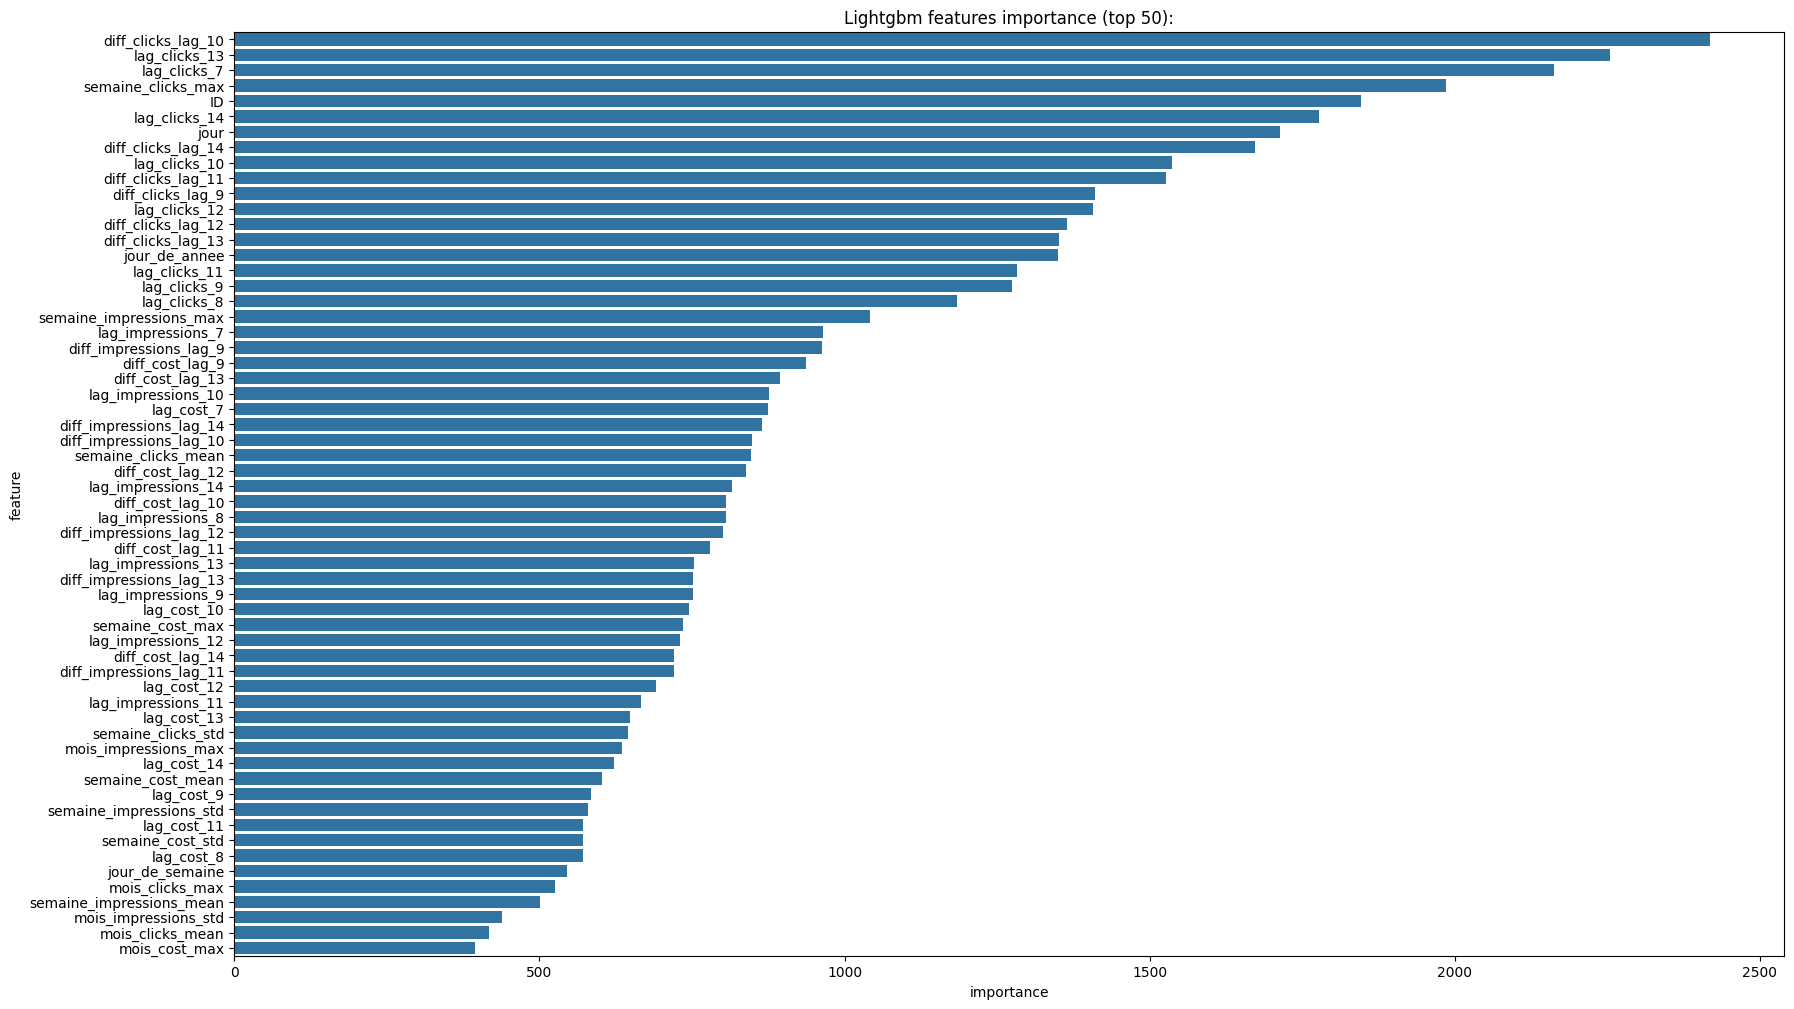

In [89]:
feature_importance = pd.DataFrame(model_lgb.feature_importances_, columns=['importance'])
feature_importance['feature'] = X

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('Lightgbm features importance (top 50):')

In [90]:
## Random Forest
scores = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit( X_train, y_train)

    preds = rf.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))


Fold 1 rmse = 68.84
Fold 2 rmse = 26.42
Fold 3 rmse = 27.14
Fold 4 rmse = 64.01
Fold 5 rmse = 26.59
RSME moyen: 42.601065348974025


Text(0.5, 1.0, 'Lightgbm features importance (top 50):')

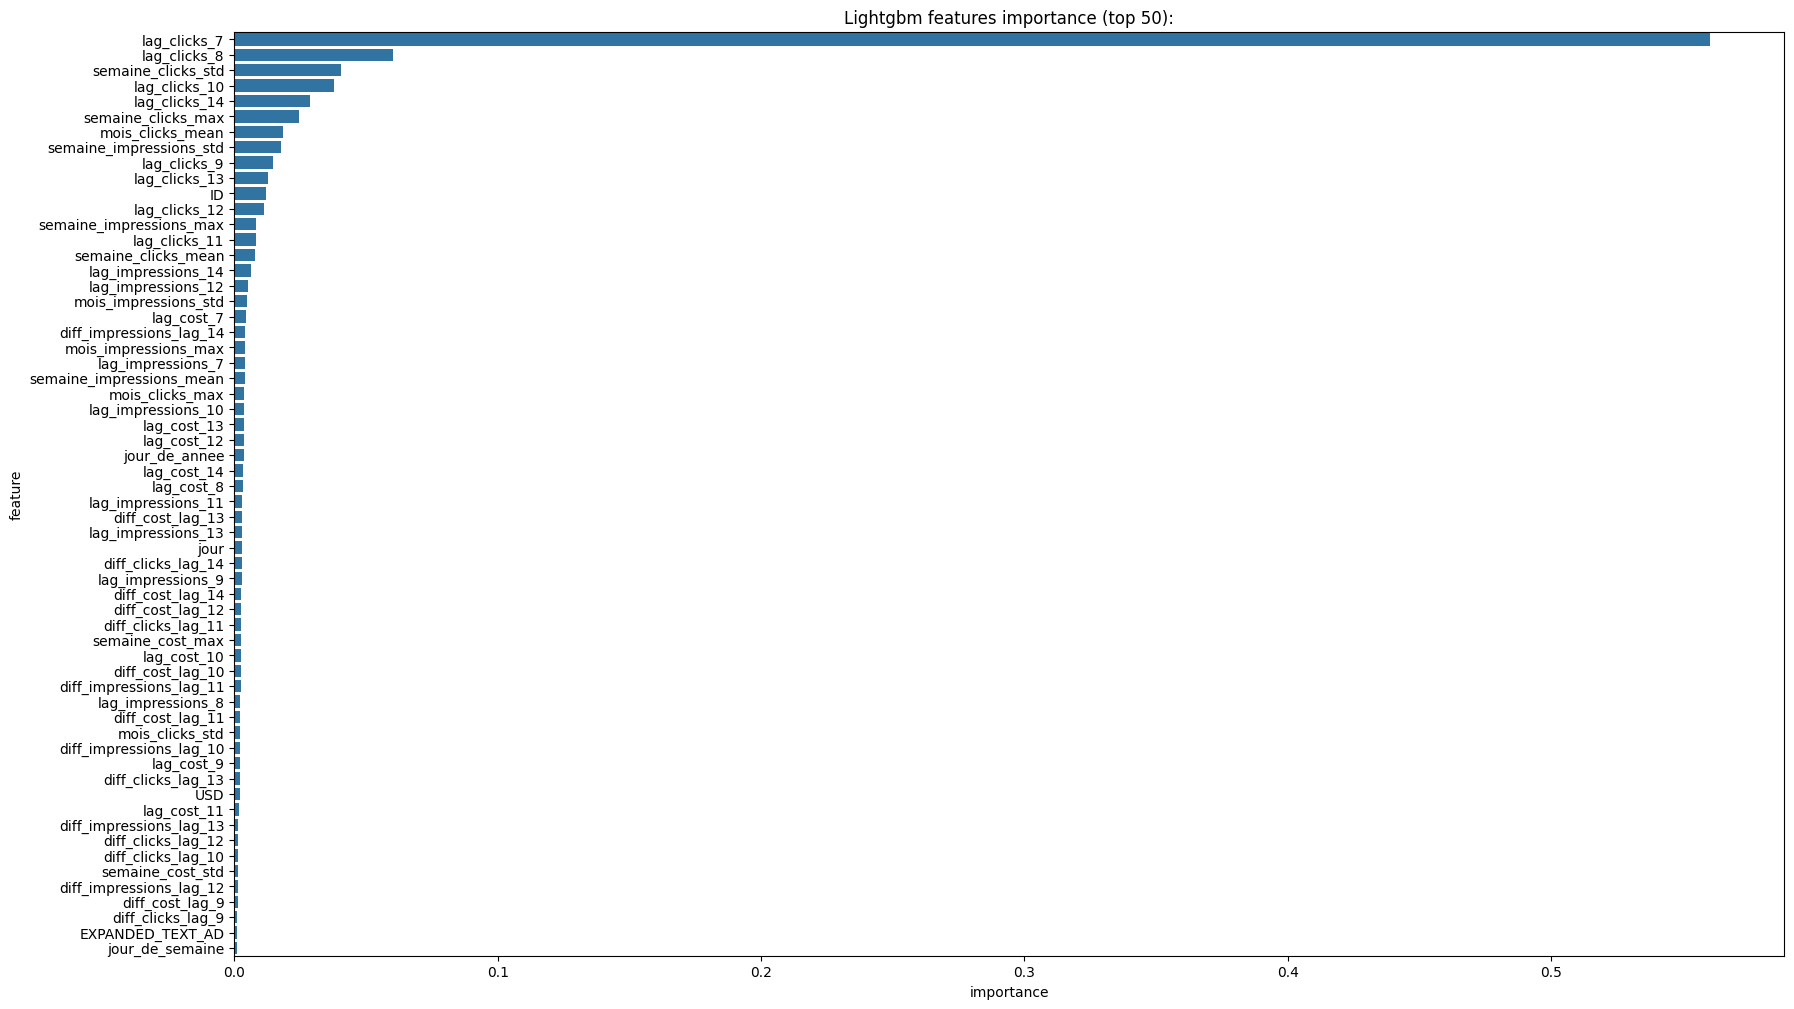

In [91]:
feature_importance = pd.DataFrame(rf.feature_importances_, columns=['importance'])
feature_importance['feature'] = X

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('Lightgbm features importance (top 50):')

In [93]:
## Xgboost
scores = []
for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = train.loc[train_idx, X], train.loc[test_idx, X]
    y_train, y_test = train.loc[train_idx, "clicks"], train.loc[test_idx, "clicks"]

    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model_xgb.fit( X_train, y_train)

    preds = model_xgb.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    scores.append(rmse)

    print(f"Fold {fold+1} rmse = {rmse:.2f}")

print("RSME moyen:", np.mean(scores))

Fold 1 rmse = 65.42
Fold 2 rmse = 25.75
Fold 3 rmse = 33.32
Fold 4 rmse = 64.86
Fold 5 rmse = 22.81
RSME moyen: 42.43044160494887


Text(0.5, 1.0, 'Lightgbm features importance (top 50):')

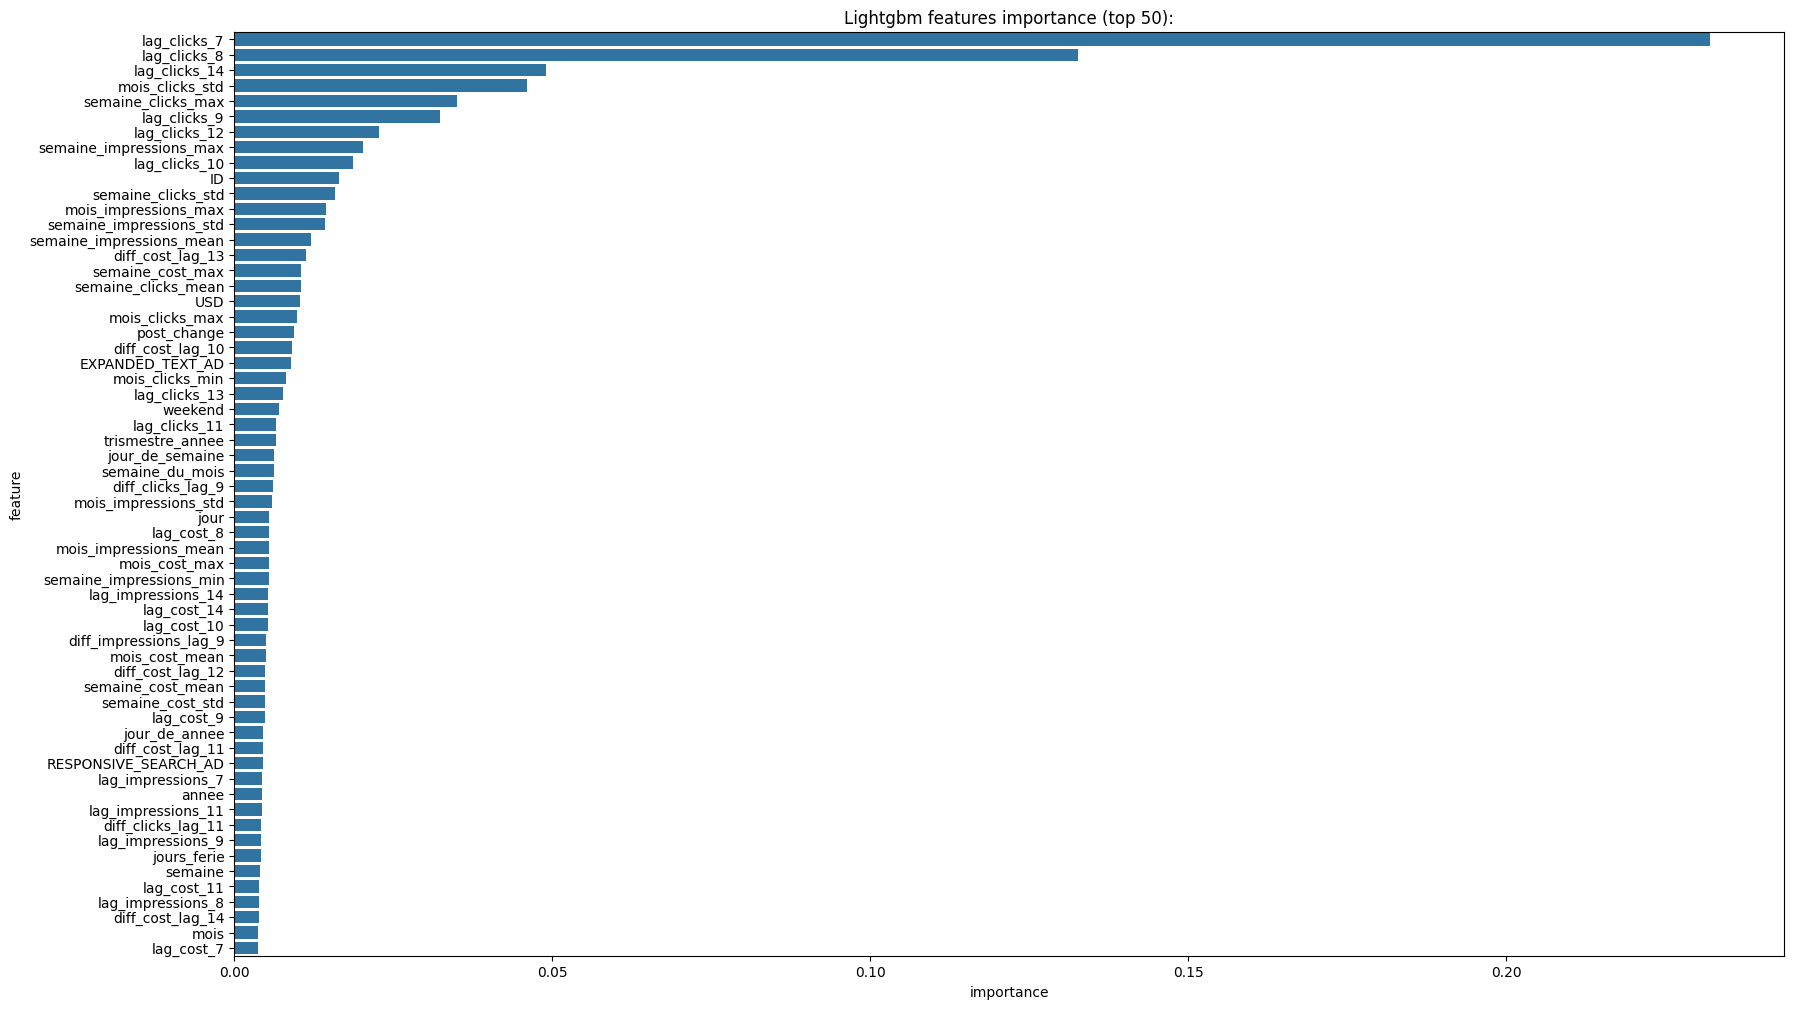

In [94]:
feature_importance = pd.DataFrame(model_xgb.feature_importances_, columns=['importance'])
feature_importance['feature'] = X

plt.figure(figsize=(20, 12))
sns.barplot(x="importance", y="feature", data=feature_importance.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('Lightgbm features importance (top 50):')

In [218]:
# num_vars = [ 'impressions', 'cost', 'conversions', 'impression_share', 'headline1_len', 'headline2_len', 'ad_description_len']
# cat_vars = ['ad_type', 'currency']
# results_num = []
# results_cat = []

# for var in num_vars:
#     df_tmp = df_train[[var, 'clicks']].dropna()
    
#     pearson_corr, pearson_p = pearsonr(df_tmp[var], df_tmp['clicks'])
#     spearman_corr, spearman_p = spearmanr(df_tmp[var], df_tmp['clicks'])
    
#     results_num.append({
#         'variable': var,
#         'pearson_corr': pearson_corr,
#         'pearson_pvalue': pearson_p,
#         'spearman_corr': spearman_corr,
#         'spearman_pvalue': spearman_p
#     })

# results_num_df = pd.DataFrame(results_num)
# display(results_num_df.sort_values('pearson_pvalue'))



# for var in cat_vars:
#     groups = [
#         df_train[df_train[var] == cat]['clicks'].dropna()
#         for cat in df_train[var].unique()
#     ]
    
#     stat, p = kruskal(*groups)
    
#     results_cat.append({
#         'variable': var,
#         'test': 'Kruskal-Wallis',
#         'p_value': p
#     })

# results_cat_df = pd.DataFrame(results_cat)
# results_cat_df